# Fake Data Analysis Pipeline

This notebook demonstrates a data analysis workflow using a synthetic dataset. It includes:
1. Data Generation
2. Data Cleaning & Transformation (Pipeline)
3. Summary Statistics
4. Visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Data Generation

We will create a fake dataset representing sales data with the following columns:
- `Date`: Daily dates over a one-year period.
- `Product_Category`: A categorical variable (Electronics, Clothing, Home, Books).
- `Sales_Amount`: Continuous variable representing revenue.
- `Units_Sold`: Integer variable representing quantity.
- `Customer_Rating`: A float between 1.0 and 5.0 (with some missing values introduced).

In [2]:
def generate_fake_data(n_rows=1000):
    dates = pd.date_range(start='2024-01-01', periods=n_rows, freq='D')
    categories = ['Electronics', 'Clothing', 'Home', 'Books']
    
    data = {
        'Date': dates,
        'Product_Category': np.random.choice(categories, n_rows),
        'Sales_Amount': np.random.uniform(10.0, 500.0, n_rows),
        'Units_Sold': np.random.randint(1, 20, n_rows),
        'Customer_Rating': np.random.uniform(1.0, 5.0, n_rows)
    }
    
    df = pd.DataFrame(data)
    
    # Introduce some noise/missing values to simulate real-world data
    mask = np.random.random(n_rows) < 0.05  # 5% missing ratings
    df.loc[mask, 'Customer_Rating'] = np.nan
    
    return df

df = generate_fake_data()
print("First 5 rows of the generated dataset:")
display(df.head())

First 5 rows of the generated dataset:


,Date,Product_Category,Sales_Amount,Units_Sold,Customer_Rating
0,2024-01-01,Home,352.099240,16,4.653148
1,2024-01-02,Books,272.687220,2,3.450294
2,2024-01-03,Electronics,161.668532,6,4.494794
3,2024-01-04,Home,408.759560,12,3.895892
4,2024-01-05,Home,345.518275,5,1.482234


## 2. Data Pipeline

Now we run a simple pipeline to:
1. Fill missing `Customer_Rating` values with the median rating of their respective category.
2. Calculate a new feature `Revenue_Per_Unit`.
3. Extract the `Month` from the `Date` column.

In [3]:
# 1. Handle Missing Values
df['Customer_Rating'] = df.groupby('Product_Category')['Customer_Rating'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Feature Engineering
df['Revenue_Per_Unit'] = df['Sales_Amount'] / df['Units_Sold']

# 3. Date Extraction
df['Month'] = df['Date'].dt.month_name()

print("Data info after pipeline processing:")
df.info()

Data info after pipeline processing:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1000 non-null   datetime64[us]
 1   Product_Category  1000 non-null   str           
 2   Sales_Amount      1000 non-null   float64       
 3   Units_Sold        1000 non-null   int64         
 4   Customer_Rating   1000 non-null   float64       
 5   Revenue_Per_Unit  1000 non-null   float64       
 6   Month             1000 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(1), str(2)
memory usage: 54.8 KB


## 3. Summary Statistics

Let's look at the statistical summary of the numerical columns and the grouping by Category.

In [4]:
display(df.describe())

# Groupby Aggregation
category_stats = df.groupby('Product_Category').agg({
    'Sales_Amount': ['sum', 'mean'],
    'Units_Sold': 'sum',
    'Customer_Rating': 'mean'
}).reset_index()

category_stats.columns = ['Category', 'Total_Sales', 'Avg_Sales', 'Total_Units', 'Avg_Rating']
display(category_stats)

,Date,Sales_Amount,Units_Sold,Customer_Rating,Revenue_Per_Unit
count,1000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-05-14 12:00:00,254.879831,9.945000,2.970707,45.834528
min,2024-01-01 00:00:00,12.269691,1.000000,1.000047,0.681650
25%,2024-09-06 18:00:00,126.097028,5.000000,2.070180,13.099556
50%,2025-05-14 12:00:00,255.265375,10.000000,2.942190,26.195288
75%,2026-01-19 06:00:00,377.367206,15.000000,3.894317,48.077666
max,2026-09-26 00:00:00,499.861660,19.000000,4.991283,467.839837
std,NaN,142.982095,5.476309,1.124344,63.667901


,Category,Total_Sales,Avg_Sales,Total_Units,Avg_Rating
0,Books,71867.822738,256.670795,2706,2.927880
1,Clothing,60213.870517,261.799437,2387,3.002572
2,Electronics,64057.217050,248.283787,2458,2.887746
3,Home,58740.921180,253.193626,2394,3.083064


## 4. Visualizations

/tmp/ipykernel_42558/843994195.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_stats, x='Category', y='Total_Sales', palette='viridis')
/tmp/ipykernel_42558/843994195.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product_Category', y='Customer_Rating', palette='pastel')


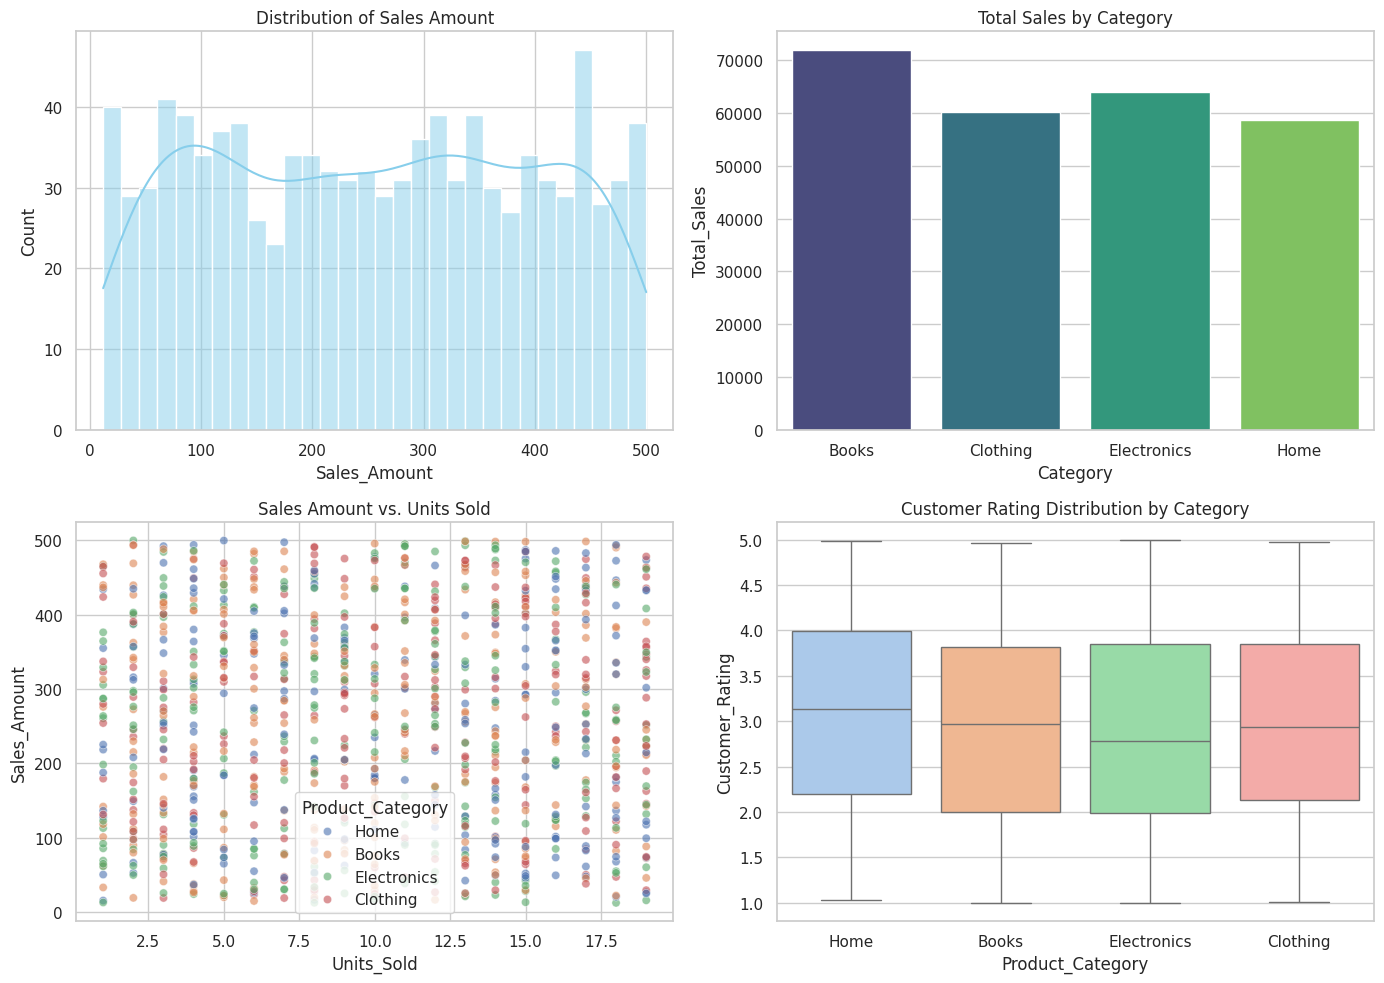

In [5]:
plt.figure(figsize=(14, 10))

# Plot 1: Sales Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['Sales_Amount'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Sales Amount')

# Plot 2: Total Sales by Category
plt.subplot(2, 2, 2)
sns.barplot(data=category_stats, x='Category', y='Total_Sales', palette='viridis')
plt.title('Total Sales by Category')

# Plot 3: Sales vs Units Sold (Scatter)
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='Units_Sold', y='Sales_Amount', hue='Product_Category', alpha=0.6)
plt.title('Sales Amount vs. Units Sold')

# Plot 4: Average Rating by Category
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='Product_Category', y='Customer_Rating', palette='pastel')
plt.title('Customer Rating Distribution by Category')

plt.tight_layout()
plt.show()